In [310]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, precision_score,
    recall_score, f1_score,
)
sns.set_theme(style="whitegrid")

In [311]:
#Data Analysis
df = pd.read_csv("Loan_default.csv")

print("Dataset shape:", df.shape)
print("\nDefault rate:", f"{df['Default'].mean():.2%}")
print("\nMissing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
df.head()

Dataset shape: (255347, 18)

Default rate: 11.61%

Missing values: 0
Duplicate rows: 0


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


##Exploratory data analysis

In [312]:
#Uniqiue values, Quantity of features
unique_default_values = df['Default'].unique()
print("\nUnique values in 'Default':")
print(unique_default_values)

default_counts = df['Default'].value_counts()
print("\nDefault counts :")
print(default_counts)

default_counts_normalized = df['Default'].value_counts(normalize=True)
print("\nDefault counts (normalized):")
print(default_counts_normalized)

###

unique_employment = df["EmploymentType"].unique()
print("\nUnique employment type",unique_employment)
employment_counts = df["EmploymentType"].value_counts()
print("\nEmployment counts",employment_counts)

###

unique_loan = df["LoanPurpose"].unique()
print("\nUnique loan purpose",unique_loan)
loan_counts = df["LoanPurpose"].value_counts()
print("\nLoan Purpose counts",loan_counts)

###

unique_education = df["Education"].unique()
print("\nUniqie education",unique_education)
education_counts = df["Education"].value_counts()
print("\nEducation counts",education_counts)

###

unique_marital = df["MaritalStatus"].unique()
print("\nUnique marital",unique_marital)
marital_counts = df["MaritalStatus"].value_counts()
print("\nMarital counts",marital_counts)


Unique values in 'Default':
[0 1]

Default counts :
Default
0    225694
1     29653
Name: count, dtype: int64

Default counts (normalized):
Default
0    0.883872
1    0.116128
Name: proportion, dtype: float64

Unique employment type ['Full-time' 'Unemployed' 'Self-employed' 'Part-time']

Employment counts EmploymentType
Part-time        64161
Unemployed       63824
Self-employed    63706
Full-time        63656
Name: count, dtype: int64

Unique loan purpose ['Other' 'Auto' 'Business' 'Home' 'Education']

Loan Purpose counts LoanPurpose
Business     51298
Home         51286
Education    51005
Other        50914
Auto         50844
Name: count, dtype: int64

Uniqie education ["Bachelor's" "Master's" 'High School' 'PhD']

Education counts Education
Bachelor's     64366
High School    63903
Master's       63541
PhD            63537
Name: count, dtype: int64

Unique marital ['Divorced' 'Married' 'Single']

Marital counts MaritalStatus
Married     85302
Divorced    85033
Single      85012
Nam

##VISUALIZATION OF FEATURES

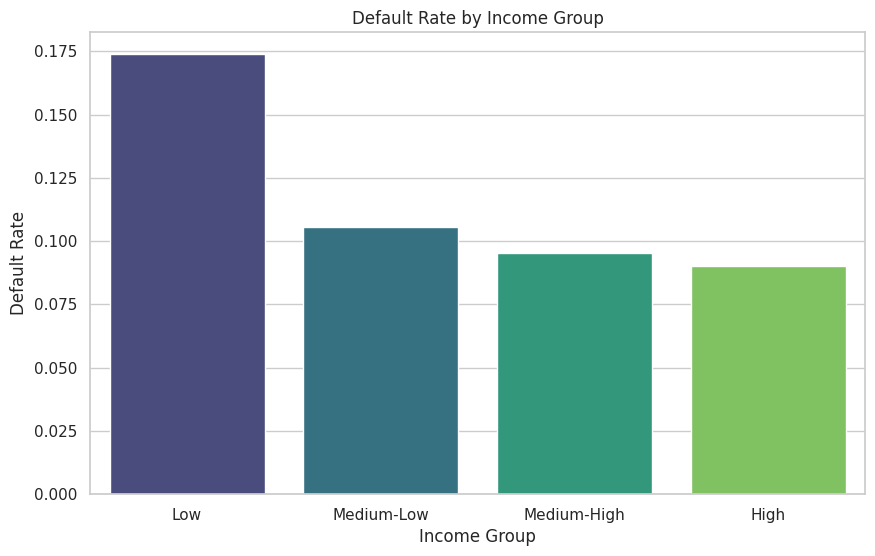

In [313]:
#Default rate by income chart visualization
income_groups = pd.qcut(df["Income"], q=4, labels=["Low", "Medium-Low", "Medium-High", "High"])
income_default_rate = df.groupby(income_groups, observed=True)["Default"].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=income_default_rate, x="Income", y="Default", hue="Income", legend=False, palette="viridis")
plt.title("Default Rate by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Default Rate")
plt.show()

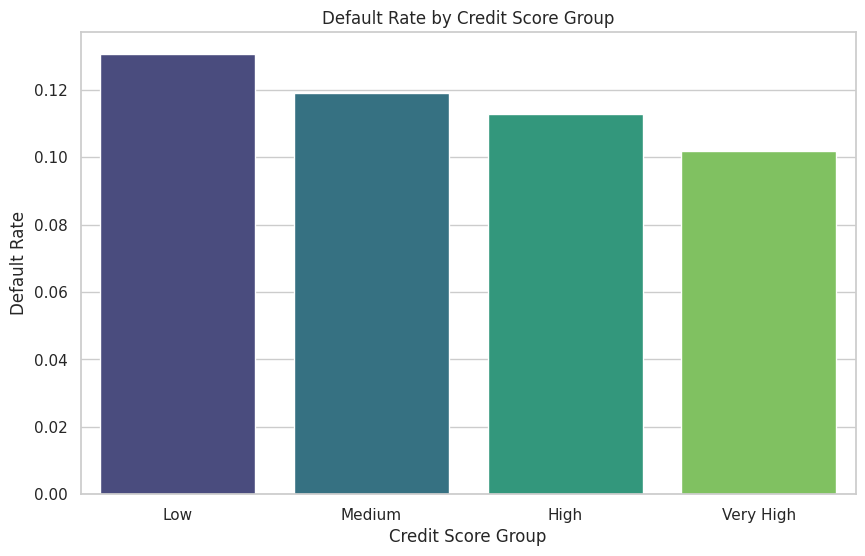

In [314]:
#Default rate by credit score chart visualization
credit_groups = pd.qcut(df["CreditScore"], q=4, labels=["Low", "Medium", "High", "Very High"])
credit_default_rate = df.groupby(credit_groups, observed=True)["Default"].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=credit_default_rate, x="CreditScore", y="Default", hue="CreditScore", legend=False, palette="viridis")
plt.title("Default Rate by Credit Score Group")
plt.xlabel("Credit Score Group")
plt.ylabel("Default Rate")
plt.show()

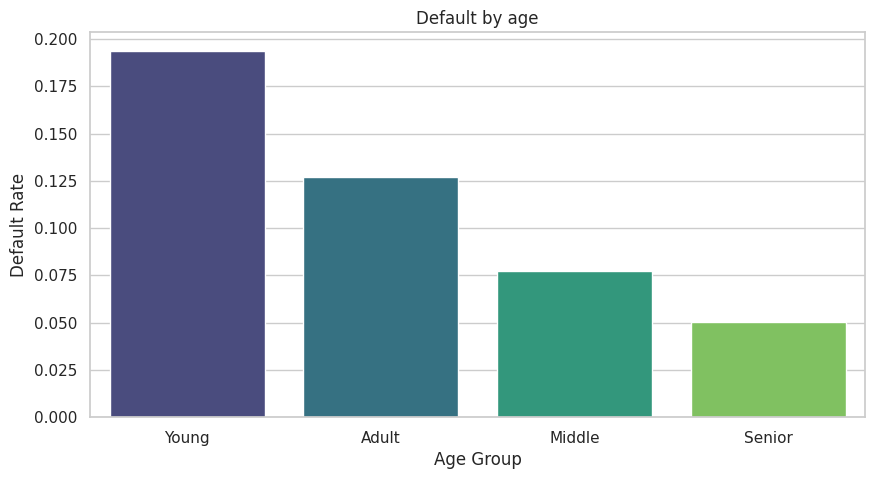

In [315]:
#Default rate by age chart visualization
age_group = pd.cut(df["Age"],bins=[17,30,45,60,100],labels=[
        "Young",
        "Adult",
        "Middle",
        "Senior"
    ]
)
age_group_by_default = df.groupby(age_group, observed=True)["Default"].mean().reset_index()
plt.figure(figsize=(10, 5))
sns.barplot(data=age_group_by_default, x="Age", y="Default", hue="Age", legend=False, palette="viridis")
plt.title("Default by age")
plt.xlabel("Age Group")
plt.ylabel("Default Rate")
plt.show()

In [316]:
#Correlation between Income, Loan Amount, and Default
df[["Income","Default","LoanAmount"]].corr()

,Income,Default,LoanAmount
Income,1.000000,-0.099119,-0.000865
Default,-0.099119,1.000000,0.086659
LoanAmount,-0.000865,0.086659,1.000000


## Feature engineering and train / validation / test split

In [317]:
#New features
df["Credit_Category"] = pd.cut(
    df["CreditScore"],
    bins=[0,300,500,700,1000],
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High"]
)

df["Loan_to_income"] = df["LoanAmount"] / df["Income"]

In [318]:
df["Loan_to_income"].describe()
df.groupby("Default")["Loan_to_income"].mean()

,Loan_to_income
Default,
0,2.036172
1,3.253000


In [319]:
pd.crosstab(
    df["Credit_Category"],
    df["Default"],
    normalize="index"
)

Default,0,1
Credit_Category,,
Very Low,0.845041,0.154959
Low,0.872440,0.127560
Medium,0.885095,0.114905
High,0.897920,0.102080


In [320]:
#Separate features (X) and target (y)
X = df.drop("Default", axis = 1)
X = X.drop("LoanID", axis = 1)
y = df["Default"]

#Train-test split. This way test set will be separate from train, avoiding data leakage
X_train_major, X_test, y_train_major, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)
X_train, X_validation, y_train, y_validation = train_test_split(X_train_major, y_train_major, test_size = 0.25, random_state =42, stratify=y_train_major)

print("Train set is", X_train.shape)
print("Validation set is", X_validation.shape)
print("Test:", X_test.shape)


#Categorical columns that need to be one-hot encoded
categorical_columns = [
    "Education",
    "EmploymentType",
    "MaritalStatus",
    "HasMortgage",
    "HasDependents",
    "LoanPurpose",
    "HasCoSigner",
    "Credit_Category"
]

#One-hot encoding
X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True,
    dtype = int
)


Train set is (153207, 18)
Validation set is (51070, 18)
Test: (51070, 18)


In [321]:
# Identify categorical columns (already defined in context, but explicit for clarity)
categorical_columns = [
    "Education",
    "EmploymentType",
    "MaritalStatus",
    "HasMortgage",
    "HasDependents",
    "LoanPurpose",
    "HasCoSigner",
    "Credit_Category"
]

# Apply one-hot encoding to each split
X_train_encoded = pd.get_dummies(X_train, columns=categorical_columns, drop_first=True, dtype=int)
X_validation_encoded = pd.get_dummies(X_validation, columns=categorical_columns, drop_first=True, dtype=int)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_columns, drop_first=True, dtype=int)

# Align columns across all datasets to ensure they have the exact same features
# This is important in case one split has a category that another does not
all_encoded_cols = list(set(X_train_encoded.columns) | set(X_validation_encoded.columns) | set(X_test_encoded.columns))

X_train = X_train_encoded.reindex(columns=all_encoded_cols, fill_value=0)
X_validation = X_validation_encoded.reindex(columns=all_encoded_cols, fill_value=0)
X_test = X_test_encoded.reindex(columns=all_encoded_cols, fill_value=0)

print("X_train shape after encoding and alignment:", X_train.shape)
print("X_validation shape after encoding and alignment:", X_validation.shape)
print("X_test shape after encoding and alignment:", X_test.shape)

X_train shape after encoding and alignment: (153207, 28)
X_validation shape after encoding and alignment: (51070, 28)
X_test shape after encoding and alignment: (51070, 28)


##LOGISTIC REGRESSION

In [322]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_validation_scaled = scaler.transform(X_validation)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight = "balanced"
)
log_model.fit(
    X_train_scaled,
    y_train
)

y_prob = log_model.predict_proba(X_test_scaled)[:,1]
y_pred = (y_prob > 0.5).astype(int) #Converted probabilities to binary predictions using a threshold (0.5)

print("\nClassification Report for Balanced Model:")
print(classification_report(y_test,y_pred))
print(f"\nROC AUC Score for Balanced Model: {roc_auc_score(y_test, y_prob)}")



Classification Report for Balanced Model:
              precision    recall  f1-score   support

           0       0.95      0.69      0.80     45139
           1       0.23      0.70      0.34      5931

    accuracy                           0.69     51070
   macro avg       0.59      0.69      0.57     51070
weighted avg       0.86      0.69      0.74     51070


ROC AUC Score for Balanced Model: 0.7617122933361922


##DECISION TREE

In [323]:
#Decision Tree

tree_model = DecisionTreeClassifier(max_depth = 6, random_state = 42)
tree_model.fit(X_train, y_train)
prediction_tree = tree_model.predict(X_test)

tree_probability = tree_model.predict_proba(X_test)[:,1]
print(classification_report(y_test, prediction_tree))
print("ROC-AUC Score:", roc_auc_score(y_test, tree_probability))


              precision    recall  f1-score   support

           0       0.89      0.99      0.94     45139
           1       0.56      0.05      0.09      5931

    accuracy                           0.89     51070
   macro avg       0.72      0.52      0.52     51070
weighted avg       0.85      0.89      0.84     51070

ROC-AUC Score: 0.7293346837621324


##RANDOM FOREST

In [324]:
rf_model = RandomForestClassifier(n_estimators = 200, max_depth = 6, random_state = 42, class_weight = "balanced", n_jobs = -1)
rf_model.fit(X_train, y_train)
prediction_rf = rf_model.predict(X_test)

rf_probability = rf_model.predict_proba(X_test)[:,1]
print(classification_report(y_test, prediction_rf))
print("ROC-AUC Score:", roc_auc_score(y_test, rf_probability))


              precision    recall  f1-score   support

           0       0.94      0.71      0.81     45139
           1       0.23      0.66      0.34      5931

    accuracy                           0.70     51070
   macro avg       0.59      0.68      0.58     51070
weighted avg       0.86      0.70      0.76     51070

ROC-AUC Score: 0.7467437260030707


##XGBoost

In [325]:
from xgboost import XGBClassifier

scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb_model = XGBClassifier(scale_pos_weight = scale_pos_weight, random_state = 42, n_estimators = 500, n_jobs = -1, max_depth = 7, learning_rate = 0.01)
xgb_model.fit(X_train, y_train)
prediciton_xgb = xgb_model.predict(X_test)

xgb_proba = xgb_model.predict_proba(X_test)[:,1]
xgb_pred = (xgb_proba > 0.5).astype(int)

print(classification_report(y_test, xgb_pred))
print("ROC-AUC Score:", roc_auc_score(y_test,xgb_proba))

              precision    recall  f1-score   support

           0       0.94      0.72      0.81     45139
           1       0.23      0.66      0.35      5931

    accuracy                           0.71     51070
   macro avg       0.59      0.69      0.58     51070
weighted avg       0.86      0.71      0.76     51070

ROC-AUC Score: 0.7554929142249825


##COMPARISON TABLE

In [326]:
def model_metrics(name, model, X_data, y_data):
    probabilities = model.predict_proba(X_data)[:, 1]
    predictions = (probabilities >= 0.50).astype(int)
    return {
        "Model": name,
        "ROC-AUC": roc_auc_score(y_data, probabilities),
        "Recall": recall_score(y_data, predictions),
        "Precision": precision_score(y_data, predictions),
        "F1-score": f1_score(y_data, predictions),
    }

comparison = pd.DataFrame([
    model_metrics("Logistic Regression (balanced)", log_model, X_validation_scaled, y_validation),
    model_metrics("Decision Tree (balanced)", tree_model, X_validation, y_validation),
    model_metrics("Random Forest (balanced)", rf_model, X_validation, y_validation),
    model_metrics("XGBoost (weighted)", xgb_model, X_validation, y_validation),
]).sort_values("ROC-AUC", ascending=False)

comparison.round(3)

,Model,ROC-AUC,Recall,Precision,F1-score
0,Logistic Regression (balanced),0.756,0.692,0.227,0.342
3,XGBoost (weighted),0.749,0.650,0.232,0.342
2,Random Forest (balanced),0.740,0.645,0.227,0.335
1,Decision Tree (balanced),0.721,0.049,0.549,0.090


##Choosing the best threshold for the final test:

In [327]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:

    y_pred_threshold = (y_prob >= threshold).astype(int)

    print("Threshold:", threshold)
    print("Recall:", round(recall_score(y_test, y_pred_threshold), 3))
    print("Precision:", round(precision_score(y_test, y_pred_threshold), 3))
    print("F1:", round(f1_score(y_test, y_pred_threshold), 3))
    print("--------------------")

Threshold: 0.1
Recall: 0.996
Precision: 0.119
F1: 0.213
--------------------
Threshold: 0.2
Recall: 0.971
Precision: 0.134
F1: 0.235
--------------------
Threshold: 0.3
Recall: 0.91
Precision: 0.156
F1: 0.266
--------------------
Threshold: 0.4
Recall: 0.82
Precision: 0.188
F1: 0.305
--------------------
Threshold: 0.5
Recall: 0.698
Precision: 0.228
F1: 0.344
--------------------
Threshold: 0.6
Recall: 0.548
Precision: 0.284
F1: 0.374
--------------------
Threshold: 0.7
Recall: 0.366
Precision: 0.36
F1: 0.363
--------------------


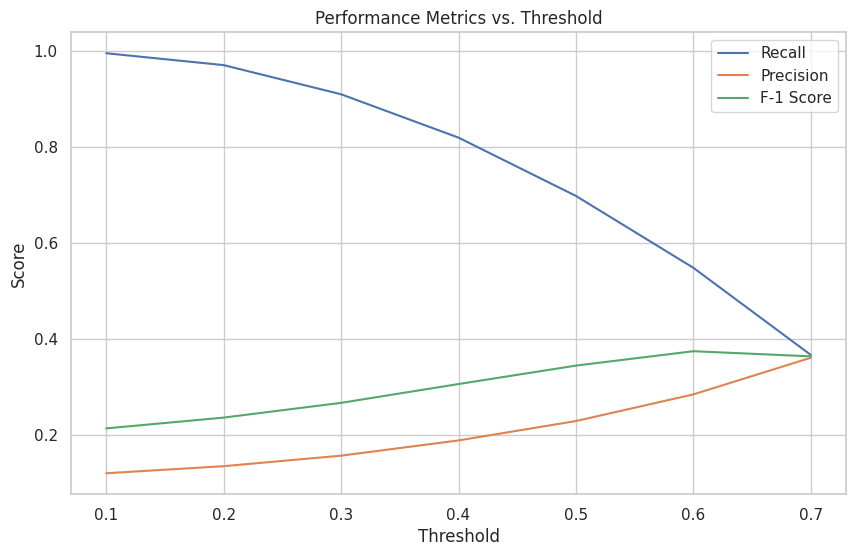

In [328]:
plt.figure(figsize=(10, 6))
plt.plot(thresholds, [recall_score(y_test, (y_prob >= threshold).astype(int)) for threshold in thresholds], label='Recall')
plt.plot(thresholds, [precision_score(y_test, (y_prob >= threshold).astype(int)) for threshold in thresholds], label='Precision')
plt.plot(thresholds, [f1_score(y_test, (y_prob >= threshold).astype(int)) for threshold in thresholds], label='F-1 Score')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Performance Metrics vs. Threshold')
plt.legend()
plt.grid(True)
plt.show()

In [329]:
def final_test_data(model, X_data, y_data, threshold):
    probabilities = model.predict_proba(X_data)[:, 1]
    predictions = (probabilities >= threshold).astype(int)
    return{
        "ROC-AUC": round(roc_auc_score(y_data, probabilities), 3),
        "Recall": round(recall_score(y_data, predictions), 3),
        "Precision": round(precision_score(y_data, predictions), 3)
    }
print("Logistic regression final test",final_test_data(log_model, X_test_scaled, y_test, 0.4))
print("Decision Tree final test",final_test_data(tree_model, X_test, y_test, 0.4))
print("Random Forest final test",final_test_data(rf_model, X_test, y_test, 0.4))
print("XGBoost Classifier final test",final_test_data(xgb_model, X_test, y_test, 0.4))

Logistic regression final test {'ROC-AUC': np.float64(0.762), 'Recall': 0.82, 'Precision': 0.188}
Decision Tree final test {'ROC-AUC': np.float64(0.729), 'Recall': 0.109, 'Precision': 0.466}
Random Forest final test {'ROC-AUC': np.float64(0.747), 'Recall': 0.88, 'Precision': 0.162}
XGBoost Classifier final test {'ROC-AUC': np.float64(0.755), 'Recall': 0.799, 'Precision': 0.191}


Here are the results of all the models, and I would choose the logistic regression model as it is easier to interprate to stakeholders and takes less time to run. My recommendations would be to tune other models in order to get better results. But for now logistic regression model is better, as it has high recall which is excellent for finding risky customers, but we compromise with precision.

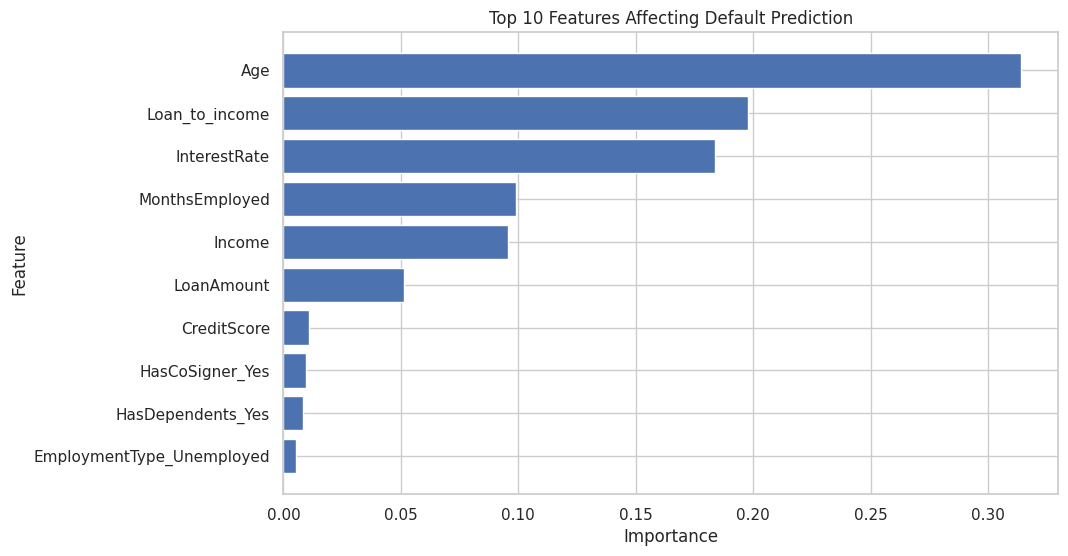

In [330]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features Affecting Default Prediction")

plt.gca().invert_yaxis()

plt.show()


I developed a binary classification model to predict loan default risk. I started with Logistic Regression as a baseline and compared it with Decision Tree, Random Forest, and XGBoost. Because the dataset had class imbalance, I applied class weighting techniques. Logistic Regression achieved the best ROC-AUC of approximately 0.76 and a default recall of 70% at the default threshold. Since missing risky customers is costly in lending, I optimized the classification threshold and selected 0.4, increasing recall to approximately 82%.

In [331]:
import joblib

joblib.dump(
    log_model,
    "loan_default_model.pkl"
)

joblib.dump(
    scaler,
    "scaler.pkl"
)

joblib.dump(
    X_train.columns.tolist(),
    "features.pkl"
)

['features.pkl']

In [332]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    log_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="roc_auc"
)

print(scores)
print(scores.mean())

[0.74911547 0.75880538 0.76054283 0.75525213 0.755405  ]
0.7558241596337839
